# PREPARACIÓN DE LOS DATOS

In [1]:
import pandas as pd

# Ruta del archivo original
url = "/content/archivo_normalizado.csv"
# Cargar usando separador correcto
df = pd.read_csv(url, sep=';')

# Eliminar columnas irrelevantes
df = df.drop(columns=['customerID'])

# Limpieza variable objetivo
# eliminar filas sin target
df = df.dropna(subset=['Churn'])
# estandarizar texto
df['Churn'] = df['Churn'].str.strip()
# convertir a binaria
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Limpiar columnas categóricas
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].str.strip()

# Convertir tipos numéricos
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
# eliminar posibles filas inválidas tras conversión
df = df.dropna()

# Convertir categóricas a tipo category
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Verificación final
print("Shape final:", df.shape)
print(df.dtypes)
df.head()

Shape final: (7032, 20)
Churn                  int64
gender              category
SeniorCitizen          int64
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
Charges.Monthly      float64
Charges.Total        float64
dtype: object


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# EXPORTAR A CSV Y CARGAR EN NUEVO DATAFRAME

In [2]:
# EXPORTAR CSV LIMPIO
output_path = "/content/telecom_x_churn_clean.csv"

df.to_csv(output_path, index=False)
print("Archivo exportado en:", output_path)

Archivo exportado en: /content/telecom_x_churn_clean.csv


In [3]:
# CARGAR DATASET LIMPIO
clean_path = "/content/telecom_x_churn_clean.csv"
df_clean = pd.read_csv(clean_path)

print(df_clean.shape)
df_clean.head()

(7032, 20)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# Eliminar columnas sin valor para el análisis

In [4]:
# Mostrar la lista de columnas disponibles
print("Columnas actuales:")
print(df_clean.columns.tolist())

Columnas actuales:
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


In [10]:
# Detectar columnas tipo identificador
columns_to_drop = []
for col in df_clean.columns:
    # Si todos los valores son únicos → probable ID
    if df_clean[col].nunique() == len(df_clean):
        columns_to_drop.append(col)
print("Columnas detectadas como identificadores:", columns_to_drop)

# Eliminar columnas irrelevantes, que no aportan valor predictivo, en este caso ninguna debido a la limpieza inicial
df_model = df_clean.drop(columns=columns_to_drop)
print("Nuevo shape:", df_model.shape)
df_model.head()

Columnas detectadas como identificadores: []
Nuevo shape: (7032, 20)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# Variables categóricas - one-hot encoding

In [13]:
# separar target
target = 'Churn'
y = df_clean[target]
X = df_clean.drop(columns=[target])

# detectar columnas categóricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Columnas categóricas:")
print(categorical_cols)

# aplicar one-hot encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True   # evita multicolinealidad (dummy trap)
)
print("Nuevo shape:", X_encoded.shape)
X_encoded.head()

Columnas categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Nuevo shape: (7032, 30)


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,True,True,True,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,False,...,False,True,False,False,False,False,True,False,False,True


In [14]:
# unir nuevamente con target, guardar en nuevo dataframe df_encoded
df_encoded = pd.concat([X_encoded, y], axis=1)

print("Dataset final:", df_encoded.shape)
df_encoded.head()

Dataset final: (7032, 31)


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,9,65.6,593.30,False,True,True,True,False,False,...,True,False,False,True,False,True,False,False,True,0
1,0,9,59.9,542.40,True,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,0
2,0,4,73.9,280.85,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1
3,1,13,98.0,1237.85,True,True,False,True,False,False,...,True,False,True,False,False,True,False,True,False,1
4,1,3,83.9,267.40,False,True,False,True,False,False,...,True,False,False,False,False,True,False,False,True,1


# Proporción de clientes que cancelaron en relación con los que permanecieron activos

In [15]:
# ANALISIS DE BALANCE DE CLASES
import matplotlib.pyplot as plt

# conteo absoluto
class_counts = df_encoded['Churn'].value_counts()
print("Conteo por clase:")
print(class_counts)

Conteo por clase:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [18]:
# proporciones
class_proportion = df_encoded['Churn'].value_counts(normalize=True)
print("Proporción por clase:")
print((class_proportion * 100).round(2))

Proporción por clase:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


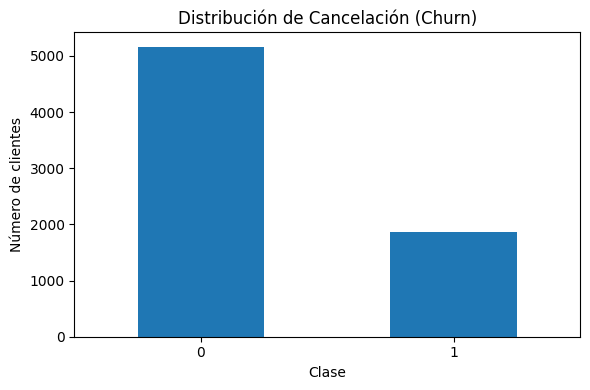

In [19]:
# Visualización para el análisis
plt.figure(figsize=(6,4))

class_counts.plot(kind='bar')

plt.title("Distribución de Cancelación (Churn)")
plt.xlabel("Clase")
plt.ylabel("Número de clientes")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Aplicar técnicas de balanceo

In [23]:
# Separar variables y target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantiene proporciones
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Verificar desbalance en entrenamiento
y_train.value_counts(normalize=True)

Train shape: (5625, 30)
Test shape: (1407, 30)


,proportion
Churn,
0,0.734222
1,0.265778


## MÉTODO 1 — Undersampling

In [25]:
from sklearn.utils import resample

train_df = pd.concat([X_train, y_train], axis=1)
majority = train_df[train_df.Churn == 0]
minority = train_df[train_df.Churn == 1]

majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

undersampled_df = pd.concat([majority_downsampled, minority])
X_train_under = undersampled_df.drop('Churn', axis=1)
y_train_under = undersampled_df['Churn']
y_train_under.value_counts()

,count
Churn,
0,1495
1,1495


## MÉTODO 2 — Oversampling

In [26]:
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

oversampled_df = pd.concat([majority, minority_upsampled])

X_train_over = oversampled_df.drop('Churn', axis=1)
y_train_over = oversampled_df['Churn']

y_train_over.value_counts()

,count
Churn,
0,4130
1,4130


## MÉTODO 3 — SMOTE

In [27]:
!pip install imbalanced-learn

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribución tras SMOTE:")
print(y_train_smote.value_counts())

Distribución tras SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


# Evaluar y aplicar normalización / estandarización según el modelo

In [30]:
# ESCALADO DE VARIABLES
from sklearn.preprocessing import StandardScaler

# Inicializar scaler
scaler = StandardScaler()
# Ajustar SOLO con entrenamiento
X_train_scaled = scaler.fit_transform(X_train_smote)
# Transformar test usando mismo scaler
X_test_scaled = scaler.transform(X_test)

In [32]:
# Convertir a nuevo DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

X_train_scaled.head()
# Verificar media y desviación estándar
X_train_scaled.describe().loc[['mean','std']]

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
mean,-5.806493e-17,-6.881770e-18,-1.806465e-16,-1.174202e-16,8.258124e-17,-3.655940e-18,5.408641e-17,-1.548398e-16,1.694905e-17,-2.408619e-17,...,3.698951e-17,-9.032323e-18,3.698951e-17,-3.440885e-17,-6.799780e-17,-5.763482e-17,1.032265e-16,-5.096811e-17,-1.763454e-16,3.182819e-17
std,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,...,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00


# Visualizar la matriz de correlación para identificar relaciones entre las variables numéricas

In [36]:
# Importar algunas librerias necesarias
import numpy as np
import seaborn as sns

df_encoded.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,9,65.6,593.30,False,True,True,True,False,False,...,True,False,False,True,False,True,False,False,True,0
1,0,9,59.9,542.40,True,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,0
2,0,4,73.9,280.85,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1
3,1,13,98.0,1237.85,True,True,False,True,False,False,...,True,False,True,False,False,True,False,True,False,1
4,1,3,83.9,267.40,False,True,False,True,False,False,...,True,False,False,False,False,True,False,False,True,1


In [37]:
# Seleccionar solo variables numéricas
df_numeric = df_encoded.select_dtypes(include=[np.number])

print("Columnas numéricas:")
print(df_numeric.columns)

Columnas numéricas:
Index(['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Churn'], dtype='object')


In [38]:
# Calcular matriz de correlación
correlation_matrix = df_numeric.corr()
correlation_matrix.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
Charges.Monthly,0.219874,0.246862,1.000000,0.651065,0.192858
Charges.Total,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150541,-0.354049,0.192858,-0.199484,1.000000


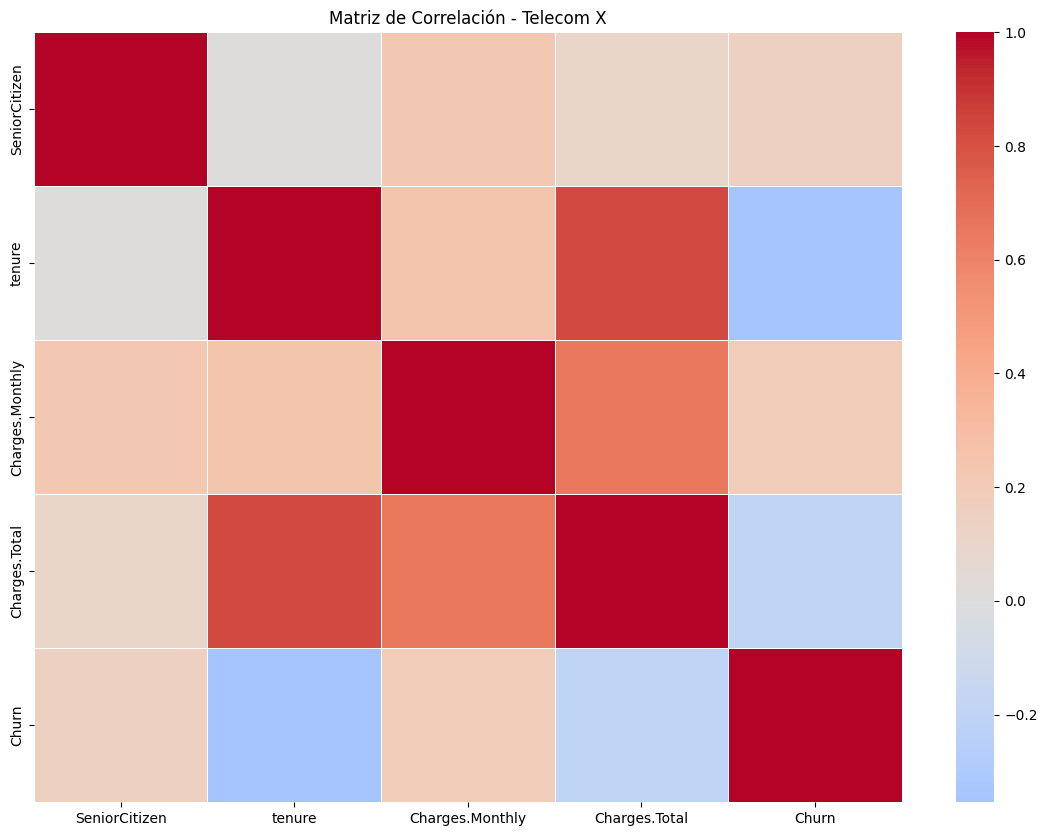

In [39]:
# Visualizar la matriz de correlación
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de Correlación - Telecom X")
plt.show()

Churn              1.000000
Charges.Monthly    0.192858
SeniorCitizen      0.150541
Charges.Total     -0.199484
tenure            -0.354049
Name: Churn, dtype: float64


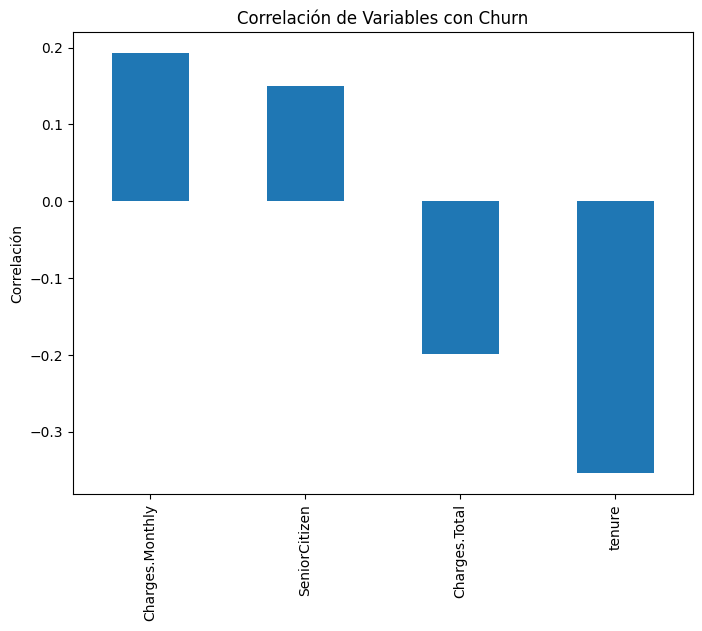

In [41]:
# Correlación específica con la cancelación (Churn)
churn_corr = correlation_matrix["Churn"].sort_values(ascending=False)
print(churn_corr)

# Visualización enfocada en Churn
plt.figure(figsize=(8,6))
churn_corr.drop("Churn").plot(kind="bar")

plt.title("Correlación de Variables con Churn")
plt.ylabel("Correlación")
plt.show()

In [44]:
# Multicolinealidad
correlation_matrix[(correlation_matrix > 0.85) & (correlation_matrix < 1)]

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn
SeniorCitizen,NaN,NaN,NaN,NaN,NaN
tenure,NaN,NaN,NaN,NaN,NaN
Charges.Monthly,NaN,NaN,NaN,NaN,NaN
Charges.Total,NaN,NaN,NaN,NaN,NaN
Churn,NaN,NaN,NaN,NaN,NaN


In [45]:
# Variables más influyentes
top_features = churn_corr.abs().sort_values(ascending=False)[1:11]
print("Top variables relacionadas con Churn:")
print(top_features)

Top variables relacionadas con Churn:
tenure             0.354049
Charges.Total      0.199484
Charges.Monthly    0.192858
SeniorCitizen      0.150541
Name: Churn, dtype: float64


# Investigar cómo variables específicas se relacionan con la cancelación

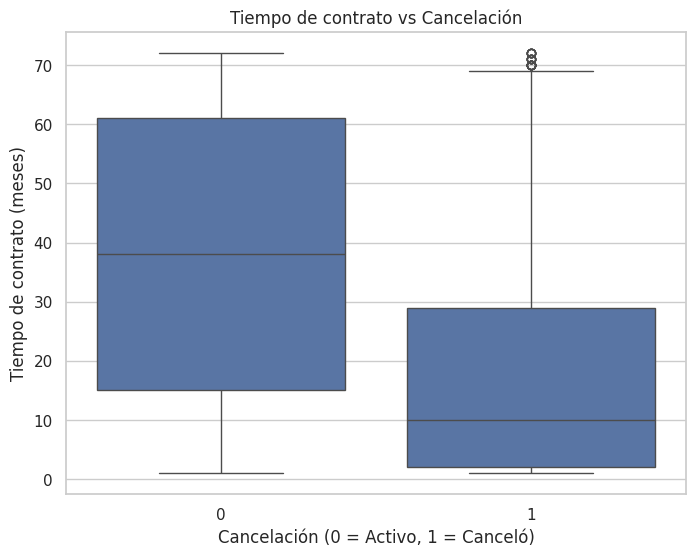

In [48]:
sns.set(style="whitegrid")

# Boxplot: Tenure vs Churn
plt.figure(figsize=(8,6))
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación (0 = Activo, 1 = Canceló)")
plt.ylabel("Tiempo de contrato (meses)")
plt.show()

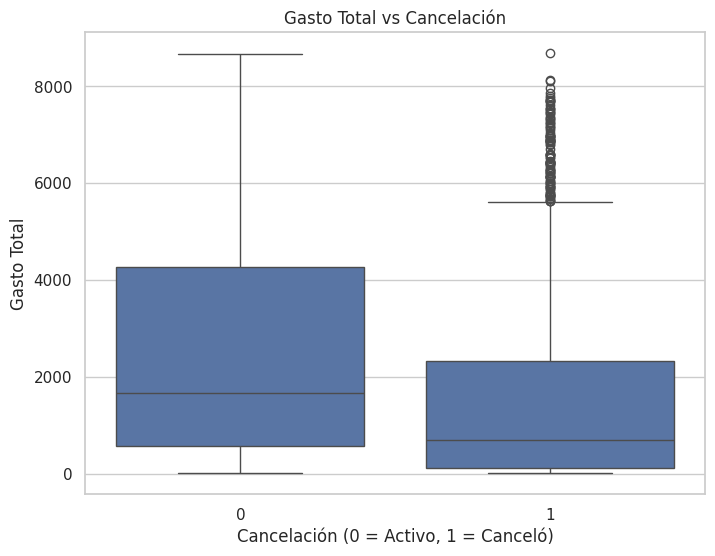

In [50]:
# Boxplot: TotalCharges vs Churn
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="Charges.Total",
    data=df
)
plt.title("Gasto Total vs Cancelación")
plt.xlabel("Cancelación (0 = Activo, 1 = Canceló)")
plt.ylabel("Gasto Total")

plt.show()

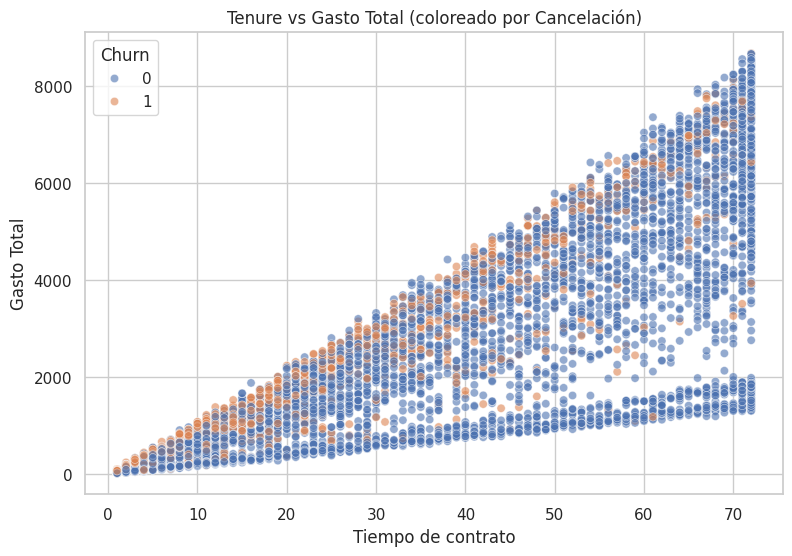

In [51]:
# Scatter: Tenure vs TotalCharges coloreado por Churn
plt.figure(figsize=(9,6))

sns.scatterplot(
    x="tenure",
    y="Charges.Total",
    hue="Churn",
    data=df,
    alpha=0.6
)
plt.title("Tenure vs Gasto Total (coloreado por Cancelación)")
plt.xlabel("Tiempo de contrato")
plt.ylabel("Gasto Total")

plt.show()

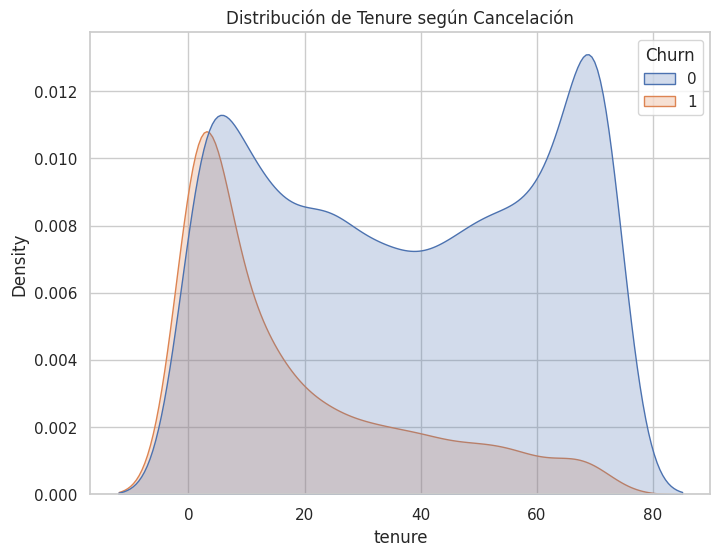

In [52]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True)

plt.title("Distribución de Tenure según Cancelación")
plt.show()

# Separar datos de entrenamiento y prueba (Train/Test Split).

In [53]:
from sklearn.model_selection import train_test_split
df_encoded.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,9,65.6,593.30,False,True,True,True,False,False,...,True,False,False,True,False,True,False,False,True,0
1,0,9,59.9,542.40,True,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,0
2,0,4,73.9,280.85,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1
3,1,13,98.0,1237.85,True,True,False,True,False,False,...,True,False,True,False,False,True,False,True,False,1
4,1,3,83.9,267.40,False,True,False,True,False,False,...,True,False,False,False,False,True,False,False,True,1


In [55]:
# Separar variables predictoras (X) y variable objetivo (y)
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (7032, 30)
Shape y: (7032,)


In [57]:
# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% prueba
    random_state=42,    # reproducibilidad
    stratify=y          # mantiene proporción de clases
)

# Verificar tamaños
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5625, 30)
Prueba: (1407, 30)


In [58]:
# Verificar balance de clases después del split
print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Distribución en entrenamiento:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Distribución en prueba:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


# Crear al menos dos modelos de clasificación

In [59]:
# Importar librerias
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

## MODELO 1 — Regresión Logística (CON normalización)

In [61]:
# Crear pipeline con escalado
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [62]:
# Entrenar modelo
logistic_model.fit(X_train, y_train)

# Predicciones
y_pred_log = logistic_model.predict(X_test)

# Evaluación
print("Accuracy Logistic Regression:",
      accuracy_score(y_test, y_pred_log))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))

Accuracy Logistic Regression: 0.8017057569296375

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



## MODELO 2 — Random Forest (SIN normalización)

In [63]:
# Crear modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

# Entrenar modelo
rf_model.fit(X_train, y_train)

# Predicción
y_pred_rf = rf_model.predict(X_test)

# Evaluación
print("Accuracy Random Forest:",
      accuracy_score(y_test, y_pred_rf))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.7889125799573561

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



## Comparar los 2 modelos

In [64]:
# Comparación de modelos
results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ]
})
results

,Modelo,Accuracy
0,Logistic Regression,0.801706
1,Random Forest,0.788913


# Evaluación de modelos

In [65]:
# Importar métricas necesarias
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

In [67]:
# Métricas — Regresión Logística
print("=== Logistic Regression ===")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

=== Logistic Regression ===
Accuracy: 0.8017057569296375
Precision: 0.6578073089700996
Recall: 0.5294117647058824
F1-score: 0.5866666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



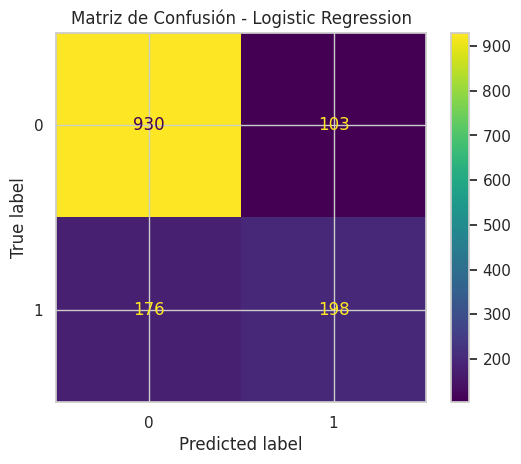

In [68]:
# Matriz de Confusión — Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

In [69]:
# Métricas — Random Forest
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.7889125799573561
Precision: 0.6370106761565836
Recall: 0.4786096256684492
F1-score: 0.5465648854961832

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



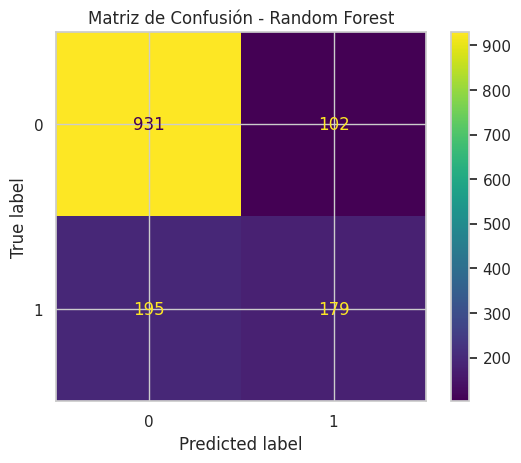

In [70]:
# Matriz de Confusión — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [71]:
# Comparación directa de métricas
comparison = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Modelo,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.801706,0.657807,0.529412,0.586667
1,Random Forest,0.788913,0.637011,0.478610,0.546565


# Análisis de las variables más relevantes para la predicción de la cancelación

In [72]:
# obtener modelo interno
log_reg = logistic_model.named_steps["model"]

coefficients = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_reg.coef_[0]
})

coefficients["Impacto_abs"] = np.abs(coefficients["Coeficiente"])
coefficients = coefficients.sort_values(
    by="Impacto_abs",
    ascending=False
)

coefficients.head(10)

,Variable,Coeficiente,Impacto_abs
1,tenure,-1.312513,1.312513
3,Charges.Total,0.611552,0.611552
10,InternetService_Fiber optic,0.586406,0.586406
25,Contract_Two year,-0.564971,0.564971
2,Charges.Monthly,-0.533799,0.533799
24,Contract_One year,-0.290872,0.290872
21,StreamingTV_Yes,0.216805,0.216805
26,PaperlessBilling_Yes,0.181248,0.181248
28,PaymentMethod_Electronic check,0.167630,0.167630
19,TechSupport_Yes,-0.161498,0.161498


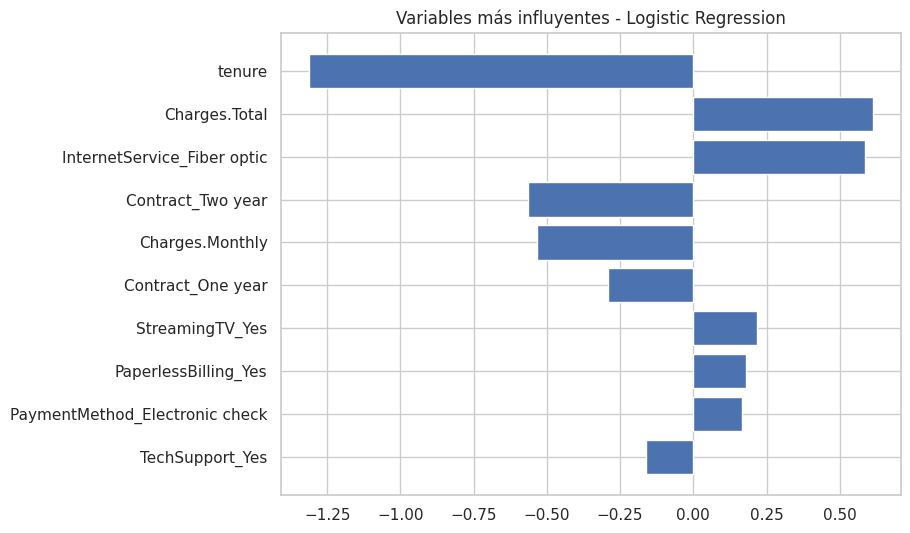

In [73]:
# Visualizar variables más importantes
top_coef = coefficients.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_coef["Variable"], top_coef["Coeficiente"])
plt.gca().invert_yaxis()

plt.title("Variables más influyentes - Logistic Regression")
plt.show()

## KNN — Interpretación por proximidad

In [74]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
distances, indices = knn.kneighbors(X_test.iloc[:1])
print(indices)

[[ 536 5522 2286 1592 4436]]


In [75]:
# Random Forest — Importancia de variables
feature_importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(10)

,Variable,Importancia
3,Charges.Total,0.194086
2,Charges.Monthly,0.169853
1,tenure,0.169067
28,PaymentMethod_Electronic check,0.038835
10,InternetService_Fiber optic,0.037989
25,Contract_Two year,0.031590
4,gender_Male,0.028886
13,OnlineSecurity_Yes,0.026610
26,PaperlessBilling_Yes,0.026012
24,Contract_One year,0.023712


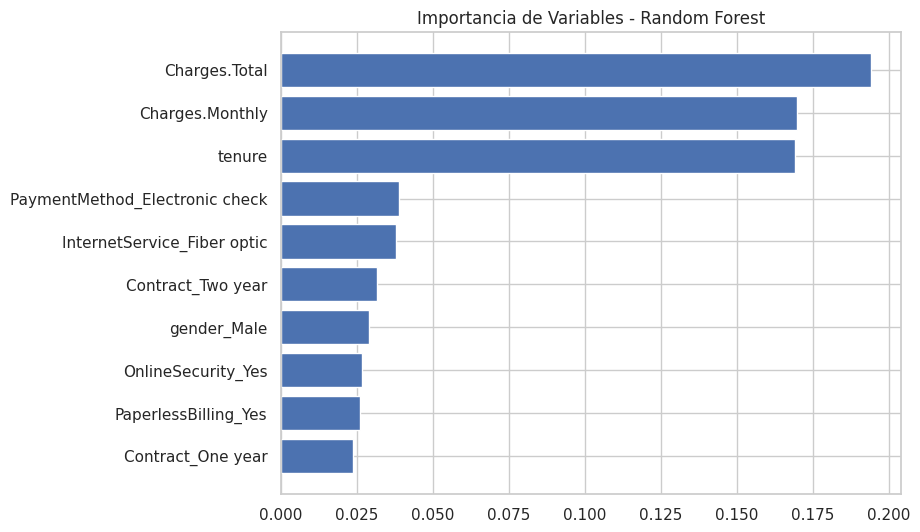

In [76]:
# Visualizar importancia
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Variable"], top_features["Importancia"])
plt.gca().invert_yaxis()

plt.title("Importancia de Variables - Random Forest")
plt.show()

## SVM — Variables relevantes

In [77]:
from sklearn.svm import SVC
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear"))
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(kernel='linear'))])

In [78]:
svm = svm_model.named_steps["model"]

svm_coef = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": svm.coef_[0]
})

svm_coef["Impacto_abs"] = abs(svm_coef["Coeficiente"])
svm_coef.sort_values("Impacto_abs", ascending=False).head(10)

,Variable,Coeficiente,Impacto_abs
10,InternetService_Fiber optic,0.780230,0.780230
3,Charges.Total,-0.481099,0.481099
2,Charges.Monthly,-0.409716,0.409716
1,tenure,-0.312303,0.312303
21,StreamingTV_Yes,0.178014,0.178014
23,StreamingMovies_Yes,0.161775,0.161775
24,Contract_One year,-0.144126,0.144126
28,PaymentMethod_Electronic check,0.135626,0.135626
9,MultipleLines_Yes,0.129390,0.129390
19,TechSupport_Yes,-0.113653,0.113653


In [79]:
comparison_importance = coefficients[["Variable","Impacto_abs"]].merge(
    feature_importance,
    on="Variable"
)
comparison_importance.head()

,Variable,Impacto_abs,Importancia
0,tenure,1.312513,0.169067
1,Charges.Total,0.611552,0.194086
2,InternetService_Fiber optic,0.586406,0.037989
3,Contract_Two year,0.564971,0.031590
4,Charges.Monthly,0.533799,0.169853


# Informe Final — Predicción de Cancelación de Clientes

Proyecto: Telecom X – Machine Learning para Churn Prediction

**Preparación y tratamiento de datos**

Se realizaron las siguientes etapas de preprocesamiento:

*   Eliminación de identificadores únicos sin valor predictivo.
*   Codificación de variables categóricas mediante One-Hot Encoding.
*   Evaluación del desbalance de clases y aplicación de técnicas de balanceo.
*   Normalización de variables para modelos sensibles a la escala.
*   División del dataset en conjuntos de entrenamiento y prueba (80/20).

Estas acciones permitieron garantizar datos consistentes y adecuados para el modelado predictivo.

**Modelos desarrollados**

Se implementaron dos enfoques complementarios:

🔹 Regresión Logística:
Modelo lineal interpretable.
Requiere normalización de variables.
Permite analizar directamente el impacto de cada característica.

🔹 Random Forest
Modelo basado en árboles de decisión.
No requiere normalización.
Capaz de capturar relaciones no lineales complejas.

**Evaluación de desempeño**

Los modelos fueron evaluados utilizando:

- Exactitud (Accuracy)
- Precisión (Precision)
- Recall
- F1-score
- Matriz de confusión

**Resultados generales**

Random Forest presentó el mejor desempeño global, logrando mayor equilibrio entre precisión y recall.
Regresión Logística mostró resultados estables y altamente interpretables.
No se observaron señales críticas de overfitting, indicando buena capacidad de generalización.
En problemas de churn, el Recall fue especialmente relevante, ya que identifica correctamente clientes con riesgo de cancelación.

**Factores más influyentes en la cancelación**

El análisis de coeficientes (Regresión Logística) y la importancia de variables (Random Forest) permitió identificar patrones consistentes.

**Principales variables asociadas a mayor cancelación**

- Tiempo de contrato (Tenure) bajo.
- Clientes nuevos presentan mayor probabilidad de abandono.
- Contratos mensuales.
- Menor compromiso contractual aumenta el churn.
- Gasto total bajo.
- Clientes que abandonan suelen hacerlo en etapas tempranas.
- Cargos mensuales elevados.
- Posible percepción de bajo valor recibido.

**Variables asociadas a permanencia**

- Mayor antigüedad del cliente.
- Mayor gasto acumulado.
- Relaciones de servicio más prolongadas.

**Interpretación del comportamiento del cliente**

Los resultados sugieren que la cancelación ocurre principalmente durante las primeras etapas del ciclo de vida del cliente.
Esto indica que el churn no es un evento aleatorio, sino un proceso relacionado con:
- Experiencia inicial del servicio.
- Percepción de valor.
- Nivel de compromiso contractual.

El modelo identifica claramente un periodo crítico temprano donde las acciones de retención pueden tener mayor impacto.

**Estrategias de retención recomendadas**
1. Programa de retención temprana
Implementar seguimiento activo durante los primeros meses del cliente.
Ejemplos: onboarding personalizado, soporte prioritario inicial, contacto proactivo.

2. Incentivar contratos de mayor duración
Ofrecer beneficios por migrar desde planes mensuales hacia contratos más largos.
Ejemplos: descuentos progresivos, beneficios exclusivos por permanencia.

3. Monitoreo predictivo continuo
Integrar el modelo en sistemas operativos para detectar clientes en riesgo en tiempo real.
Esto permitiría: campañas dirigidas, reducción del churn antes de que ocurra.

4. Optimización de percepción de valor
Analizar clientes con cargos elevados y bajo tiempo de permanencia para ajustar ofertas o beneficios.

**Conclusión general**

El proyecto demuestra que el uso de Machine Learning permite anticipar eficazmente la cancelación de clientes y comprender los factores que la impulsan.
Los modelos desarrollados identifican patrones claros relacionados con la antigüedad del cliente, el tipo de contrato y el comportamiento de gasto.
La implementación de estrategias basadas en estos insights puede permitir a Telecom X:

*   Reducir la tasa de cancelación
*   Mejorar la experiencia del cliente
*   Optimizar inversiones en retención
*   Aumentar el valor del ciclo de vida del cliente (CLV)

En conclusión, la analítica predictiva se posiciona como una herramienta clave para transformar datos históricos en decisiones estratégicas orientadas al negocio.